In [1]:
import csv
import os
import pandas as pd
import collections
import ast
import time
import collections
import json
import sqlite3
import xxhash
import numpy as np
import pickle 
import random
import glob
from io import StringIO
from pathlib import Path
from openai import OpenAI, AsyncOpenAI
import openai
print(openai.__version__)
os.environ["OPENAI_API_KEY"] = ''

openai.api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(
    # defaults to os.environ.get("OPENAI_API_KEY")
    api_key=os.getenv("OPENAI_API_KEY"),
)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from prompts.all_prompts import *
from order_by.sorting import *
from order_by.utils import *
from order_by.optimizer import *

In [3]:
import matplotlib.pyplot as plt

In [4]:
def sortedness(gold_list, sorted_data):
    kendalltau = kendalltau_distance(gold_list[:], sorted_data[:])
    return kendalltau

def tokens2price(model, in_tokens, out_tokens):
    """
    Calculate the API cost given the model and number of input/output tokens.

    Pricing (as of Sep 2025):
    - gpt-4o:       $2.50 per 1M input tokens, $10.00 per 1M output tokens
    - gpt-4o-mini:  $0.150 per 1M input tokens, $0.600 per 1M output tokens
    """
    if model == 'gpt-4o':
        input_rate = 2.50 / 1_000_000
        output_rate = 10.00 / 1_000_000
    elif model == 'gpt-4o-mini':
        input_rate = 0.150 / 1_000_000
        output_rate = 0.600 / 1_000_000
    else:
        raise ValueError(f"Unknown model: {model}")

    total_cost = in_tokens * input_rate + out_tokens * output_rate
    return round(total_cost, 6) 
        
        
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}' 

In [5]:
random.seed(0)
dataname = "population_by_country_2020"

fname = f"{dataname}.csv"
file_path = f"../data/{fname}"
data = pd.read_csv(file_path)

sorted_df = data.sort_values(by=["Population (2020)", "Country"], ascending=[True, True])
print(len(sorted_df))
    
gold_list = sorted_df["Country"].tolist()
print(gold_list[:10])
shuffled_list = random.sample(gold_list, len(gold_list)) # shuffle the sorted list

235
['Holy See', 'Tokelau', 'Niue', 'Falkland Islands', 'Montserrat', 'Saint Pierre & Miquelon', 'Saint Helena', 'Saint Barthelemy', 'Nauru', 'Wallis & Futuna']


In [8]:

for modelname, budget in [("gpt-4o-mini", 0.5), ("gpt-4o-mini", 5), ("gpt-4o", 1), ("gpt-4o", 20)]:

    optimizer = OrderByOptimizer(client, shuffled_list[:], 
                                membership_inference_prompt.format_map(SafeDict(description="country 2020 population")),
                                population_pointwise_prompt_template,
                                population_external_pointwise_prompt_template,
                                population_pairwise_comparison_prompt_template,
                                population_external_comparison_prompt_template,
                                budget, modelname, isPassage=False)

    sorted_data, num_api_calls, in_tokens, out_tokens = await optimizer.physical_order_by_impl()
    kendalltau = sortedness(gold_list, sorted_data)
    print(f'budget: {budget}')
    print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")

ext_bubble_4 estimated cost 1.0999762499999999
ext_bubble_6 estimated cost 0.5779433333333333
ext_bubble_8 estimated cost 0.22466
ext_merge_4 estimated cost 0.07271916670992487
from window m=2: 5.518 from window 2m: 5.5
Final memory size for external pointwise: m = 8
as the best ['Tokelau', 'Saint Pierre & Miquelon', 'Saint Martin', 'Sint Maarten', 'Marshall Islands', 'U.S. Virgin Islands', 'Grenada', 'Samoa', 'Sao Tome & Principe', 'Western Sahara']
point estimated cost 0.033161857142857146
ext_point estimated cost 0.012038714285714286
quick estimated cost 0.13300472736431845
ext_merge_4 estimated cost 0.09859701795828947
ext_bubble_8 estimated cost 0.17409092673992677
ext_bubble_4 estimated cost 1.1083950115830117
------------------
decided to use point
------------------
budget: 0.5
kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.

ext_bubble_4 estimated cost 1.0999762499999999
ext_merge_4 estimated cost 0.07271916670992487
from window m=2: 5.518 from window 2m:

In [ ]:
decided to use point
------------------
budget: 0.5
kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.
decided to use ext_bubble_4
------------------
budget: 5
kendalltau score: 0.992798690671031, tokens: 2903423, price: 1.142571.
            
            
decided to use point
------------------
budget: 1
kendalltau score: 0.9949081651209309, tokens: 60394, price: 0.530898.
decided to use ext_merge_4
------------------
budget: 20
kendalltau score: 0.9932351336606654, tokens: 213139, price: 1.286088.

In [12]:
async def experiment(dataname, sort_by_columns, column_to_compare, log_filename, pointwise_prompt_template,\
               external_pointwise_prompt_template, external_comparison_prompt_template,\
               pairwise_comparison_prompt_template, tolerance = 0.01, out_t = float):
    random.seed(0)
    
    fname = f"{dataname}.csv"
    file_path = f"./data/{fname}"
    data = pd.read_csv(file_path)

    sorted_df = data.sort_values(by=sort_by_columns, ascending=[True, True])
    print(len(sorted_df))
    
    gold_list = sorted_df[column_to_compare].tolist()
    print(gold_list[:10])
    shuffled_list = random.sample(gold_list, len(gold_list)) # shuffle the sorted list

    results = {}
    # "gpt-5-2025-08-07" too expensive
    for modelname in ["gpt-4o-mini", "gpt-4o"]:
        memory_sizes = [8, 16]
        if modelname == 'gpt-4o-mini':
            memory_sizes = [4, 8]
        print(modelname)
        
        sorted_data, num_api_calls, in_tokens, out_tokens, confidences = await pointwise_sort(shuffled_list[:], client, pointwise_prompt_template, modelname, out_t)
        kendalltau = sortedness(gold_list, sorted_data)
        print("pointwise_sort")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n {confidences}")

        sorted_data, num_api_calls, in_tokens, out_tokens = await quick_sort(shuffled_list[:], client, pairwise_comparison_prompt_template, modelname, False, 1)
        kendalltau = sortedness(gold_list, sorted_data)
        print("quick_sort")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")

        votes = 3
        sorted_data, num_api_calls, in_tokens, out_tokens = await quick_sort(shuffled_list[:], client, pairwise_comparison_prompt_template, modelname, False, votes)
        kendalltau = sortedness(gold_list, sorted_data)
        print(f"quick_sort with vote={votes}")
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")


        sorted_data, num_api_calls, in_tokens, out_tokens, confidences = await external_pointwise_sort(shuffled_list[:], external_values, client, external_pointwise_prompt_template, modelname, out_t, tolerance)
        kendalltau = sortedness(gold_list, sorted_data)
        print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n {confidences}\n")

    
        for m in memory_sizes:
            sorted_data, num_api_calls, in_tokens, out_tokens = await external_bubble_sort(shuffled_list[:], external_comparisons, m, client, external_comparison_prompt_template, modelname)
            print(f"external_bubble_sort sorted data length {len(sorted_data)}")
            kendalltau = sortedness(gold_list, sorted_data)
            print(f"external_bubble_sort {m}")
            print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}\n")


            sorted_data, num_api_calls, in_tokens, out_tokens = await external_merge_sort(shuffled_list[:], external_comparisons, m, client, external_comparison_prompt_template, modelname)
            print(f"external_merge_sort sorted data length {len(sorted_data)}")
            kendalltau = sortedness(gold_list, sorted_data)
            print(f"external_merge_sort {m}")
            print(f"kendalltau score: {kendalltau}, tokens: {in_tokens+out_tokens}, price: {tokens2price(modelname, in_tokens, out_tokens)}.\n")


In [13]:
dataname = "population_by_country_2020"
column_to_sort = "Country"
log_filename = "./logs/nba_heights.json"
await experiment(
         dataname,
        ["Population (2020)", "Country"],
        "Country",
        log_filename,
        population_pointwise_prompt_template,
        population_external_pointwise_prompt_template, 
        population_external_comparison_prompt_template,
        population_pairwise_comparison_prompt_template,
        1.0,
        float
    )

235
['Holy See', 'Tokelau', 'Niue', 'Falkland Islands', 'Montserrat', 'Saint Pierre & Miquelon', 'Saint Helena', 'Saint Barthelemy', 'Nauru', 'Wallis & Futuna']
gpt-4o-mini
pointwise_sort
kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.
 [9, 9, 8, 9, 8, 8, 8, 8, 9, 9, 8, 9, 9, 8, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 8, 9, 9, 9, 8, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 7, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 9, 9, 9, 9, 9, 9, 9, 10, 9, 10]
quick_sort
kendalltau score: 0.9

# Figures

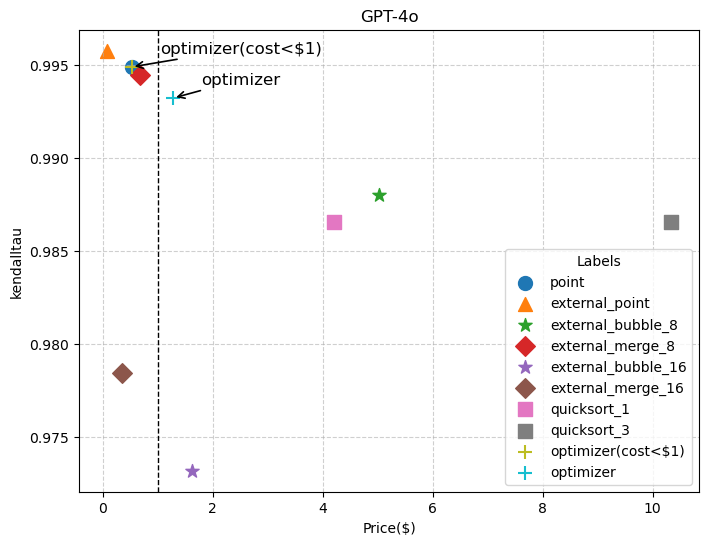

In [14]:
from scipy.optimize import curve_fit
# pointwise_sort, kendalltau score: 0.9949081651209309, tokens: 60394, price: 0.530898
# external pointwise: m = 32 (agreement = 1.00) kendalltau score: 0.9957810511001999, tokens: 9682, price: 0.084873

# quick_sort kendalltau score: 0.9865430078196035, tokens: 513732, price: 4.1991
# quick_sort with vote=3 kendalltau score: 0.9865430078196035, tokens: 1256401, price: 10.330773


# external_bubble_sort 8 kendalltau score: 0.9879978177850517, tokens: 773476, price: 5.027583
# external_merge_sort 8 kendalltau score: 0.9944717221312965, tokens: 103012, price: 0.670285.

# external_bubble_sort 16 kendalltau score: 0.9731587561374795, tokens: 243187, price: 1.62586
# external_merge_sort 16 kendalltau score: 0.9783960720130932, tokens: 52646, price: 0.356735.


            
kendalltau = [0.9949081651209309, 0.9957810511001999, 
              0.9879978177850517, 0.9944717221312965,
              0.9731587561374795, 0.9783960720130932,
              0.9865430078196035, 0.9865430078196035
             ]
tokens = [60394, 9682,
          773476, 103012,
          243187, 52646,
          513732, 1256401
         ]

prices = [0.530898, 0.084873,
          5.027583, 0.670285,
          1.62586, 0.356735,
          4.1991, 10.330773
         ]

dot_labels = ["point", "external_point",\
              "external_bubble_8", "external_merge_8",\
              "external_bubble_16", "external_merge_16",\
              "quicksort_1", "quicksort_3"
             ]
markers = ['o', '^',\
           '*', 'D',
           '*', 'D',
           's', 's'
          ] 


            
# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)

# decided to use point
# ------------------
# budget: 1
# kendalltau score: 0.9949081651209309, tokens: 60394, price: 0.530898.
# decided to use ext_merge_4
# ------------------
# budget: 20
# kendalltau score: 0.9932351336606654, tokens: 213139, price: 1.286088.

plt.scatter(0.530898, 0.9949081651209309, s=100, marker='+', label='optimizer(cost<$1)')

plt.annotate(
    'optimizer(cost<$1)',
    xy=(0.530898, 0.9949081651209309),
    xytext=(20, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)

plt.scatter(1.286088,  0.9932351336606654, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(1.286088,  0.9932351336606654),
    xytext=(20, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)



    
    

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("Price($)")
plt.ylabel("kendalltau")
plt.title("GPT-4o")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
            

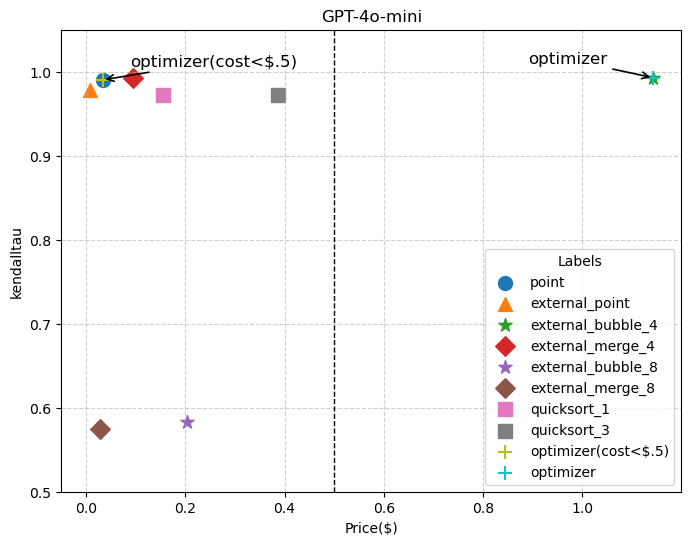

In [24]:
# pointwise_sort, kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.
# external pointwise: m = 8 (agreement = 1.00) kendalltau score: 0.9781051100200036, tokens: 17043, price: 0.006958.

# quick_sort kendalltau score: 0.9722858701582106, tokens: 451839, price: 0.155748.
# quick_sort with vote=3 kendalltau score: 0.9724313511547553, tokens: 1111593, price: 0.386788.

# external_bubble_sort 4 kendalltau score: 0.992798690671031, tokens: 2903423, price: 1.142571
# external_merge_sort 4 kendalltau score: 0.9919985451900345, tokens: 242709, price: 0.095249.

#external_bubble_sort 8 kendalltau score: 0.5830514639025277, tokens: 608108, price: 0.20267
# external_merge_sort 8 kendalltau score: 0.5744680851063829, tokens: 80960, price: 0.027603.

# optimizer
# budget 0.5
# kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.
# unlimited
# kendalltau score: 0.992798690671031, tokens: 2903423, price: 1.142571.

kendalltau = [0.9902527732314965, 0.9781051100200036,
              0.992798690671031, 0.9919985451900345,
              0.5830514639025277, 0.5744680851063829,
              0.9722858701582106, 0.9724313511547553
             ]
tokens = [ 62629, 17043,
          2903423, 242709,
          608108, 80960,
          451839, 1111593
         ]
prices = [0.033195, 0.006958,
          1.142571,0.095249,
          0.20267, 0.02760,
          0.155748, 0.386788
         ]


dot_labels = ["point", "external_point",\
              "external_bubble_4", "external_merge_4",
              "external_bubble_8", "external_merge_8",
              "quicksort_1", "quicksort_3",\
             ]
markers = ['o', '^', '*', 'D',\
           "*", "D",\
           's', 's'
          ] 


# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)

# decided to use point
# ------------------
# budget: 0.5
# kendalltau score: 0.9902527732314965, tokens: 62629, price: 0.033195.

# decided to use ext_bubble_4
# ------------------
# budget: 5
# kendalltau score: 0.992798690671031, tokens: 2903423, price: 1.142571.
            

plt.scatter(0.033195, 0.9902527732314965, s=100, marker='+', label='optimizer(cost<$.5)')

plt.annotate(
    'optimizer(cost<$.5)',
    xy=(0.033195, 0.9902527732314965),
    xytext=(20, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=.5, color='black', linestyle='--', linewidth=1)

plt.scatter(1.142571,  0.992798690671031, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(1.142571,  0.992798690671031),
    xytext=(-90, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)


    
plt.ylim(0.5, 1.05)
plt.legend(title="Labels")

# Axis labels and title
plt.xlabel("Price($)")
plt.ylabel("kendalltau")
plt.title("GPT-4o-mini")


# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()